# Unsupervised Learning Trading Strategy

* Download/Load SP500 stocks prices data.
* Calculate different features and indicators on each stock.
* Aggregate on monthly level and filter top 150 most liquid stocks.
* Calculate Monthly Returns for different time-horizons.
* Download Fama-French Factors and Calculate Rolling Factor Betas.
* For each month fit a K-Means Clustering Algorithm to group similar assets based on their features.
* For each month select assets based on the cluster and form a portfolio based on Efficient Frontier max sharpe ratio optimization.
* Visualize Portfolio returns and compare to SP500 returns.

# All Packages Needed:
* pandas, numpy, matplotlib, statsmodels, pandas_datareader, datetime, yfinance, sklearn, PyPortfolioOpt

## 1. Download/Load SP500 stocks prices data.

In [2]:
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import warnings
!pip install pandas_ta
import pandas_ta
warnings.filterwarnings('ignore')

In [3]:
hpam = ['INDF.JK', 'ICBP.JK', 'DNET.JK', 'AMMN.JK', 'BINA.JK', 'LSIP.JK', 'SIMP.JK', 'IMAS.JK', 'IMJS.JK', 'DCII.JK', 'PANI.JK', 'MEDC.JK', 'EMTK.JK', 'MEGA.JK', 'BUMI.JK', 'BRMS.JK', 'DEWA.JK', 'UNIC.JK', 'FAST.JK', 'JECC.JK', 'BRPT.JK', 'BREN.JK', 'TPIA.JK', 'CUAN.JK', 'PTRO.JK', 'RATU.JK', 'SSIA.JK', 'CDIA.JK', 'ALII.JK', 'BNBR.JK', 'BRMS.JK', 'BUMI.JK', 'DEWA.JK', 'ENRG.JK', 'UNSP.JK', 'VKTR.JK']

end_date = '2025-07-31'

start_date = pd.to_datetime(end_date)-pd.DateOffset(365*7)

df = yf.download(tickers=hpam,
                 start=start_date,
                 end=end_date).stack()

df.index.names = ['date', 'ticker']

df.columns = df.columns.str.lower()

df

[*********************100%***********************]  33 of 33 completed


Price                     close         high          low         open  \
date       ticker                                                        
2018-08-02 BINA.JK   575.000000   605.000000   560.000000   605.000000   
           BNBR.JK  3800.000000  3800.000000  3800.000000  3800.000000   
           BRMS.JK    57.565670    61.054497    56.693462    57.565670   
           BRPT.JK   354.003235   364.760230   351.069490   360.848590   
           BUMI.JK   258.000000   270.000000   258.000000   260.000000   
...                         ...          ...          ...          ...   
2025-07-30 SSIA.JK  2700.000000  2790.000000  2700.000000  2770.000000   
           TPIA.JK  9269.926758  9394.858385  9269.926758  9394.858385   
           UNIC.JK  7733.553711  7757.949779  7733.553711  7757.949779   
           UNSP.JK   129.000000   130.000000   129.000000   129.000000   
           VKTR.JK    84.000000    86.000000    82.000000    85.000000   

Price                    volume  
date       ticker                
2018-08-02 BINA.JK     687900.0  
           BNBR.JK          0.0  
           BRMS.JK  176278082.0  
           BRPT.JK   48170600.0  
           BUMI.JK  234115200.0  
...                         ...  
2025-07-30 SSIA.JK   46901700.0  
           TPIA.JK    4234600.0  
           UNIC.JK       3000.0  
           UNSP.JK    1182500.0  
           VKTR.JK   19061300.0  

[46222 rows x 5 columns]

## 2. Calculate features and technical indicators for each stock.

* Garman-Klass Volatility
* RSI
* Bollinger Bands
* ATR
* MACD
* Dollar Volume

\begin{equation}
\text{Garman-Klass Volatility} = \frac{(\ln(\text{High}) - \ln(\text{Low}))^2}{2} - (2\ln(2) - 1)(\ln(\text{Adj Close}) - \ln(\text{Open}))^2
\end{equation}

In [4]:
import numpy as np
import pandas as pd # Ensure pandas is imported if it's not already

df['garman_klass_vol'] = ((np.log(df['high'])-np.log(df['low']))**2)/2-(2*np.log(2)-1)*((np.log(df['close'])-np.log(df['open']))**2)
df['rsi'] = df.groupby(level=1)['close'].transform(lambda x: pandas_ta.rsi(close=x, length=20))

# Helper function to safely get a Bollinger Band component
def get_bb_component_safe(series_x, component_index, length=20):
    # Calculate bbands for the log-transformed series
    bb_result = pandas_ta.bbands(close=np.log1p(series_x), length=length)

    # If bbands returns None or an empty DataFrame, return a Series of NaNs
    if bb_result is None or bb_result.empty:
        return pd.Series(np.nan, index=series_x.index)

    # Otherwise, return the requested component
    return bb_result.iloc[:, component_index]

# Apply the safe helper function for each Bollinger Band component
df['bb_low'] = df.groupby(level=1)['close'].transform(lambda x: get_bb_component_safe(x, 0))
df['bb_mid'] = df.groupby(level=1)['close'].transform(lambda x: get_bb_component_safe(x, 1))
df['bb_high'] = df.groupby(level=1)['close'].transform(lambda x: get_bb_component_safe(x, 2))

def compute_atr(stock_data):
    atr = pandas_ta.atr(high=stock_data['high'],
                        low=stock_data['low'],
                        close=stock_data['close'],
                        length=14)
    return atr.sub(atr.mean()).div(atr.std())

df['atr'] = df.groupby(level=1, group_keys=False).apply(compute_atr)

# Robustified compute_macd function
def compute_macd(close_series):
    macd_result = pandas_ta.macd(close=close_series, length=20)
    if macd_result is None or macd_result.empty:
        return pd.Series(np.nan, index=close_series.index)

    macd_line = macd_result.iloc[:,0]

    # Handle cases where std is 0 or all NaNs after calculation
    if macd_line.isnull().all() or macd_line.std() == 0:
        return pd.Series(np.nan, index=close_series.index)

    return macd_line.sub(macd_line.mean()).div(macd_line.std())

df['macd'] = df.groupby(level=1, group_keys=False)['close'].apply(compute_macd)

df['dollar_volume'] = (df['close']*df['volume'])/1e6

df

Price                     close         high          low         open  \
date       ticker                                                        
2018-08-02 BINA.JK   575.000000   605.000000   560.000000   605.000000   
           BNBR.JK  3800.000000  3800.000000  3800.000000  3800.000000   
           BRMS.JK    57.565670    61.054497    56.693462    57.565670   
           BRPT.JK   354.003235   364.760230   351.069490   360.848590   
           BUMI.JK   258.000000   270.000000   258.000000   260.000000   
...                         ...          ...          ...          ...   
2025-07-30 SSIA.JK  2700.000000  2790.000000  2700.000000  2770.000000   
           TPIA.JK  9269.926758  9394.858385  9269.926758  9394.858385   
           UNIC.JK  7733.553711  7757.949779  7733.553711  7757.949779   
           UNSP.JK   129.000000   130.000000   129.000000   129.000000   
           VKTR.JK    84.000000    86.000000    82.000000    85.000000   

Price                    volume  garman_klass_vol        rsi    bb_low  \
date       ticker                                                        
2018-08-02 BINA.JK     687900.0          0.001988        NaN       NaN   
           BNBR.JK          0.0          0.000000        NaN       NaN   
           BRMS.JK  176278082.0          0.002746        NaN       NaN   
           BRPT.JK   48170600.0          0.000590        NaN       NaN   
           BUMI.JK  234115200.0          0.001010        NaN       NaN   
...                         ...               ...        ...       ...   
2025-07-30 SSIA.JK   46901700.0          0.000285  70.737237  7.304470   
           TPIA.JK    4234600.0          0.000020  47.849027  9.087306   
           UNIC.JK       3000.0          0.000001  52.853929  8.931070   
           UNSP.JK    1182500.0          0.000030  63.639671  4.755996   
           VKTR.JK   19061300.0          0.001080  47.497946  4.408475   

Price                 bb_mid   bb_high       atr      macd  dollar_volume  
date       ticker                                                          
2018-08-02 BINA.JK       NaN       NaN       NaN       NaN     395.542500  
           BNBR.JK       NaN       NaN       NaN       NaN       0.000000  
           BRMS.JK       NaN       NaN       NaN       NaN   10147.565899  
           BRPT.JK       NaN       NaN       NaN       NaN   17052.548225  
           BUMI.JK       NaN       NaN       NaN       NaN   60401.721600  
...                      ...       ...       ...       ...            ...  
2025-07-30 SSIA.JK  7.732365  8.160261  7.226231  7.649083  126634.590000  
           TPIA.JK  9.165869  9.244431  1.341043 -0.963257   39254.431849  
           UNIC.JK  8.944719  8.958368 -0.510896 -0.159934      23.200661  
           UNSP.JK  4.821382  4.886769 -0.964275  0.814872     152.542500  
           VKTR.JK  4.448328  4.488181 -0.994514  0.093300    1601.149200  

[46222 rows x 13 columns]

## 3. Aggregate to monthly level and filter top 150 most liquid stocks for each month.

* To reduce training time and experiment with features and strategies, we convert the business-daily data to month-end frequency.

In [5]:
# First, prepare the dollar_volume as it needs mean aggregation
dollar_volume_monthly = df.unstack('ticker')['dollar_volume'].resample('M').mean().stack('ticker').to_frame('dollar_volume')

# Then, prepare all other columns using 'last' aggregation
# This list now explicitly includes 'close' along with other feature columns
other_cols_for_monthly = [col for col in df.columns.unique(0) if col not in ['dollar_volume', 'volume', 'open', 'high', 'low']]

# Resample and stack these columns
other_features_monthly = df.unstack('ticker')[other_cols_for_monthly].resample('M').last().stack('ticker')

# Concatenate dollar_volume and other features
data = pd.concat([dollar_volume_monthly, other_features_monthly], axis=1).dropna()

data

dollar_volume        close  garman_klass_vol        rsi  \
date       ticker                                                             
2018-09-30 BINA.JK     363.862285   620.000000          0.000275  73.957386   
           BRMS.JK    3059.940197    55.821255          0.003236  61.075303   
           BRPT.JK   15113.364261   359.870667          0.000106  56.392073   
           BUMI.JK   30153.864760   216.000000          0.000389  42.025078   
           DNET.JK     123.460502  3278.317871          0.000027  40.620792   
...                           ...          ...               ...        ...   
2025-07-31 SSIA.JK  203829.329705  2700.000000          0.000285  70.737237   
           TPIA.JK  129534.052421  9269.926758          0.000020  47.849027   
           UNIC.JK      21.079533  7733.553711          0.000001  52.853929   
           UNSP.JK     100.051700   129.000000          0.000030  63.639671   
           VKTR.JK    1492.954714    84.000000          0.001080  47.497946   

                      bb_low    bb_mid   bb_high       atr      macd  
date       ticker                                                     
2018-09-30 BINA.JK  6.177537  6.298481  6.419425 -0.728876 -0.002394  
           BRMS.JK  3.801082  3.922737  4.044392 -0.568377 -0.192785  
           BRPT.JK  5.718905  5.823445  5.927984 -1.321940 -0.072539  
           BUMI.JK  5.347923  5.394282  5.440640  1.063998 -0.537818  
           DNET.JK  8.092526  8.098733  8.104940 -0.580867 -0.246479  
...                      ...       ...       ...       ...       ...  
2025-07-31 SSIA.JK  7.304470  7.732365  8.160261  7.226231  7.649083  
           TPIA.JK  9.087306  9.165869  9.244431  1.341043 -0.963257  
           UNIC.JK  8.931070  8.944719  8.958368 -0.510896 -0.159934  
           UNSP.JK  4.755996  4.821382  4.886769 -0.964275  0.814872  
           VKTR.JK  4.408475  4.448328  4.488181 -0.994514  0.093300  

[2168 rows x 9 columns]

* Calculate 5-year rolling average of dollar volume for each stocks before filtering.

In [6]:
data['dollar_volume'] = (data.loc[:, 'dollar_volume'].unstack('ticker').rolling(5*12, min_periods=12).mean().stack())

data['dollar_vol_rank'] = (data.groupby('date')['dollar_volume'].rank(ascending=False))

data = data[data['dollar_vol_rank']<150].drop(['dollar_volume', 'dollar_vol_rank'], axis=1)

data

close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                        
2019-08-31 BINA.JK   840.000000          0.001617  39.893471  6.748212   
           BRMS.JK    45.354771          0.001023  61.225454  3.766749   
           BRPT.JK   890.862854          0.000337  70.390037  6.455075   
           BUMI.JK    94.000000          0.000715  36.786077  4.476781   
           DNET.JK  3078.420410          0.000005  47.846245  8.028014   
...                         ...               ...        ...       ...   
2025-07-31 SSIA.JK  2700.000000          0.000285  70.737237  7.304470   
           TPIA.JK  9269.926758          0.000020  47.849027  9.087306   
           UNIC.JK  7733.553711          0.000001  52.853929  8.931070   
           UNSP.JK   129.000000          0.000030  63.639671  4.755996   
           VKTR.JK    84.000000          0.001080  47.497946  4.408475   

                      bb_mid   bb_high       atr      macd  
date       ticker                                           
2019-08-31 BINA.JK  6.798480  6.848747 -0.565759 -0.277413  
           BRMS.JK  3.806535  3.846321 -0.844967 -0.141131  
           BRPT.JK  6.627588  6.800102 -0.144888  0.664111  
           BUMI.JK  4.584605  4.692429 -0.360631 -0.934421  
           DNET.JK  8.036214  8.044415 -0.554829 -0.212835  
...                      ...       ...       ...       ...  
2025-07-31 SSIA.JK  7.732365  8.160261  7.226231  7.649083  
           TPIA.JK  9.165869  9.244431  1.341043 -0.963257  
           UNIC.JK  8.944719  8.958368 -0.510896 -0.159934  
           UNSP.JK  4.821382  4.886769 -0.964275  0.814872  
           VKTR.JK  4.448328  4.488181 -0.994514  0.093300  

[1821 rows x 8 columns]

## 4. Calculate Monthly Returns for different time horizons as features.

* To capture time series dynamics that reflect, for example, momentum patterns, we compute historical returns using the method .pct_change(lag), that is, returns over various monthly periods as identified by lags.

In [7]:
def calculate_returns(df):

    outlier_cutoff = 0.005

    lags = [1, 2, 3, 6, 9, 12]

    for lag in lags:

        df[f'return_{lag}m'] = (df['close'] # Changed from 'adj close' to 'close'
                              .pct_change(lag)
                              .pipe(lambda x: x.clip(lower=x.quantile(outlier_cutoff),
                                                     upper=x.quantile(1-outlier_cutoff)))
                              .add(1)
                              .pow(1/lag)
                              .sub(1))
    return df


data = data.groupby(level=1, group_keys=False).apply(calculate_returns).dropna()

data

close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                        
2020-08-31 BINA.JK   825.000000          0.000642  40.611167  6.713247   
           BRMS.JK    43.610355          0.000196  44.181132  3.797966   
           BRPT.JK   826.878174          0.000720  30.541454  6.737472   
           BUMI.JK    50.000000          0.000000  34.093706  3.931826   
           DNET.JK  3398.256348          0.001269  50.246009  8.101621   
...                         ...               ...        ...       ...   
2025-07-31 SSIA.JK  2700.000000          0.000285  70.737237  7.304470   
           TPIA.JK  9269.926758          0.000020  47.849027  9.087306   
           UNIC.JK  7733.553711          0.000001  52.853929  8.931070   
           UNSP.JK   129.000000          0.000030  63.639671  4.755996   
           VKTR.JK    84.000000          0.001080  47.497946  4.408475   

                      bb_mid   bb_high       atr      macd  return_1m  \
date       ticker                                                       
2020-08-31 BINA.JK  6.740431  6.767615 -0.821322 -0.246777  -0.062500   
           BRMS.JK  3.797966  3.797966 -0.960323 -0.201374   0.000000   
           BRPT.JK  6.794853  6.852234 -0.079275 -1.351757  -0.115790   
           BUMI.JK  3.931826  3.931826 -1.738105  0.101666   0.000000   
           DNET.JK  8.138186  8.174751 -0.218388 -0.031474  -0.014493   
...                      ...       ...       ...       ...        ...   
2025-07-31 SSIA.JK  7.732365  8.160261  7.226231  7.649083   0.664393   
           TPIA.JK  9.165869  9.244431  1.341043 -0.963257  -0.060759   
           UNIC.JK  8.944719  8.958368 -0.510896 -0.159934   0.009554   
           UNSP.JK  4.821382  4.886769 -0.964275  0.814872   0.084034   
           VKTR.JK  4.448328  4.488181 -0.994514  0.093300  -0.023256   

                    return_2m  return_3m  return_6m  return_9m  return_12m  
date       ticker                                                           
2020-08-31 BINA.JK  -0.065647  -0.071307  -0.028287  -0.009621   -0.001500  
           BRMS.JK   0.000000   0.000000   0.000000   0.000000   -0.003263  
           BRPT.JK  -0.149037  -0.146281  -0.026191  -0.052130   -0.006192  
           BUMI.JK   0.000000   0.000000   0.000000  -0.028731   -0.051246  
           DNET.JK  -0.014389  -0.009616  -0.004820   0.012144    0.008271  
...                       ...        ...        ...        ...         ...  
2025-07-31 SSIA.JK   0.587670   0.444895   0.181707   0.092948    0.078562  
           TPIA.JK  -0.002394   0.056263   0.045646   0.006560   -0.003249  
           UNIC.JK  -0.066893   0.043164   0.008571   0.002230    0.005612  
           UNSP.JK   0.024100   0.024400   0.023832   0.016838    0.037431  
           VKTR.JK   0.012122  -0.026328  -0.057713  -0.060972   -0.035572  

[1457 rows x 14 columns]

## 5. Download Fama-French Factors and Calculate Rolling Factor Betas.

* We will introduce the Fama—French data to estimate the exposure of assets to common risk factors using linear regression.

* The five Fama—French factors, namely market risk, size, value, operating profitability, and investment have been shown empirically to explain asset returns and are commonly used to assess the risk/return profile of portfolios. Hence, it is natural to include past factor exposures as financial features in models.

* We can access the historical factor returns using the pandas-datareader and estimate historical exposures using the RollingOLS rolling linear regression.

In [8]:
factor_data = web.DataReader('F-F_Research_Data_5_Factors_2x3',
                               'famafrench',
                               start='2010')[0].drop('RF', axis=1)

factor_data.index = factor_data.index.to_timestamp()
factor_data = factor_data.resample('M').last().div(100)
factor_data.index.name = 'date'
factor_data = factor_data.join(data['return_1m']).sort_index()

factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                    
2020-08-31 BINA.JK  0.0762 -0.0089 -0.0302  0.0427 -0.0151  -0.062500
           BRMS.JK  0.0762 -0.0089 -0.0302  0.0427 -0.0151   0.000000
           BRPT.JK  0.0762 -0.0089 -0.0302  0.0427 -0.0151  -0.115790
           BUMI.JK  0.0762 -0.0089 -0.0302  0.0427 -0.0151   0.000000
           DNET.JK  0.0762 -0.0089 -0.0302  0.0427 -0.0151  -0.014493
...                    ...     ...     ...     ...     ...        ...
2025-07-31 SSIA.JK  0.0198 -0.0015 -0.0127 -0.0029 -0.0207   0.664393
           TPIA.JK  0.0198 -0.0015 -0.0127 -0.0029 -0.0207  -0.060759
           UNIC.JK  0.0198 -0.0015 -0.0127 -0.0029 -0.0207   0.009554
           UNSP.JK  0.0198 -0.0015 -0.0127 -0.0029 -0.0207   0.084034
           VKTR.JK  0.0198 -0.0015 -0.0127 -0.0029 -0.0207  -0.023256

[1457 rows x 6 columns]

* Filter out stocks with less than 10 months of data.

In [9]:
observations = factor_data.groupby(level=1).size()

valid_stocks = observations[observations >= 10]
factor_data = factor_data[factor_data.index.get_level_values('ticker').isin(valid_stocks.index)]

factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                    
2020-08-31 BINA.JK  0.0762 -0.0089 -0.0302  0.0427 -0.0151  -0.062500
           BRMS.JK  0.0762 -0.0089 -0.0302  0.0427 -0.0151   0.000000
           BRPT.JK  0.0762 -0.0089 -0.0302  0.0427 -0.0151  -0.115790
           BUMI.JK  0.0762 -0.0089 -0.0302  0.0427 -0.0151   0.000000
           DNET.JK  0.0762 -0.0089 -0.0302  0.0427 -0.0151  -0.014493
...                    ...     ...     ...     ...     ...        ...
2025-07-31 SIMP.JK  0.0198 -0.0015 -0.0127 -0.0029 -0.0207   0.352374
           SSIA.JK  0.0198 -0.0015 -0.0127 -0.0029 -0.0207   0.664393
           TPIA.JK  0.0198 -0.0015 -0.0127 -0.0029 -0.0207  -0.060759
           UNIC.JK  0.0198 -0.0015 -0.0127 -0.0029 -0.0207   0.009554
           UNSP.JK  0.0198 -0.0015 -0.0127 -0.0029 -0.0207   0.084034

[1442 rows x 6 columns]

* Calculate Rolling Factor Betas.

In [12]:
betas = (factor_data.groupby(level=1,
                            group_keys=False)
         .apply(lambda x: RollingOLS(endog=x['return_1m'],
                                     exog=sm.add_constant(x.drop('return_1m', axis=1)),
                                     window=min(24, x.shape[0]),
                                     min_nobs=len(x.columns)+1)
         .fit(params_only=True)
         .params
         .drop('const', axis=1)))

betas

Mkt-RF       SMB       HML       RMW       CMA
date       ticker                                                   
2020-08-31 BINA.JK       NaN       NaN       NaN       NaN       NaN
           BRMS.JK       NaN       NaN       NaN       NaN       NaN
           BRPT.JK       NaN       NaN       NaN       NaN       NaN
           BUMI.JK       NaN       NaN       NaN       NaN       NaN
           DNET.JK       NaN       NaN       NaN       NaN       NaN
...                      ...       ...       ...       ...       ...
2025-07-31 SIMP.JK -0.299400  0.911711 -0.681885 -0.790861  0.485184
           SSIA.JK  0.539288  1.125871 -3.415559  0.750015  4.730598
           TPIA.JK -0.612355  1.893816  0.510291  1.381170  2.910537
           UNIC.JK  0.672062  0.659779 -1.331493  1.479835  1.513255
           UNSP.JK -0.592357  1.413853 -0.800405 -2.325758 -1.409884

[1442 rows x 5 columns]

* Join the rolling factors data to the main features dataframe.

In [13]:
factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

data = (data.join(betas.groupby(level='ticker').shift(), rsuffix='_beta'))

# Update 'factors' to refer to the newly named beta columns
factors = [f'{f}_beta' for f in factors]

data.loc[:, factors] = data.groupby(level='ticker', group_keys=False)[factors].apply(lambda x: x.fillna(x.mean()))

data = data.drop('close', axis=1)

data = data.dropna()

data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 842 entries, (Timestamp('2022-08-31 00:00:00'), 'BINA.JK') to (Timestamp('2025-07-31 00:00:00'), 'UNSP.JK')
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   garman_klass_vol  842 non-null    float64
 1   rsi               842 non-null    float64
 2   bb_low            842 non-null    float64
 3   bb_mid            842 non-null    float64
 4   bb_high           842 non-null    float64
 5   atr               842 non-null    float64
 6   macd              842 non-null    float64
 7   return_1m         842 non-null    float64
 8   return_2m         842 non-null    float64
 9   return_3m         842 non-null    float64
 10  return_6m         842 non-null    float64
 11  return_9m         842 non-null    float64
 12  return_12m        842 non-null    float64
 13  Mkt-RF            842 non-null    float64
 14  SMB               842 non-null    float64
 15  HML  

### At this point we have to decide on what ML model and approach to use for predictions etc.


## 6. For each month fit a K-Means Clustering Algorithm to group similar assets based on their features.

### K-Means Clustering
* You may want to initialize predefined centroids for each cluster based on your research.

* For visualization purpose of this tutorial we will initially rely on the ‘k-means++’ initialization.

* Then we will pre-define our centroids for each cluster.

In [14]:
from sklearn.cluster import KMeans

# Check if 'cluster' column exists before dropping
if 'cluster' in data.columns:
    data = data.drop('cluster', axis=1)

def get_clusters(df):
    df['cluster'] = KMeans(n_clusters=4,
                           random_state=0,
                           # init=initial_centroids # Temporarily removed to avoid NameError
                          ).fit(df).labels_
    return df

data = data.dropna().groupby('date', group_keys=False).apply(get_clusters)

data

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                               
2022-08-31 BINA.JK          0.000454  53.135183  8.226959  8.247693  8.268427   
           BRMS.JK          0.000427  55.908056  5.357951  5.453787  5.549624   
           BRPT.JK          0.000635  40.260263  6.655645  6.837176  7.018708   
           BUMI.JK          0.003554  70.212056  4.618316  4.936309  5.254302   
           DNET.JK          0.000130  57.265091  8.183715  8.209803  8.235890   
...                              ...        ...       ...       ...       ...   
2025-07-31 SIMP.JK          0.012681  86.486291  6.147929  6.289269  6.430610   
           SSIA.JK          0.000285  70.737237  7.304470  7.732365  8.160261   
           TPIA.JK          0.000020  47.849027  9.087306  9.165869  9.244431   
           UNIC.JK          0.000001  52.853929  8.931070  8.944719  8.958368   
           UNSP.JK          0.000030  63.639671  4.755996  4.821382  4.886769   

                         atr      macd  return_1m  return_2m  return_3m  ...  \
date       ticker                                                        ...   
2022-08-31 BINA.JK  0.061548 -0.181122  -0.020356   0.002608  -0.011009  ...   
           BRMS.JK  0.601726  0.427657   0.059829   0.004057   0.028424  ...   
           BRPT.JK -0.228921 -0.618854  -0.088889   0.042158  -0.006024  ...   
           BUMI.JK  2.527537  3.883478   0.486726   0.521362   0.376293  ...   
           DNET.JK  0.110507  0.069797   0.019022   0.059601   0.049934  ...   
...                      ...       ...        ...        ...        ...  ...   
2025-07-31 SIMP.JK  5.466062  4.520840   0.352374   0.285044   0.190543  ...   
           SSIA.JK  7.226231  7.649083   0.664393   0.587670   0.444895  ...   
           TPIA.JK  1.341043 -0.963257  -0.060759  -0.002394   0.056263  ...   
           UNIC.JK -0.510896 -0.159934   0.009554  -0.066893   0.043164  ...   
           UNSP.JK -0.964275  0.814872   0.084034   0.024100   0.024400  ...   

                         SMB       HML       RMW       CMA  Mkt-RF_beta  \
date       ticker                                                         
2022-08-31 BINA.JK -1.474143 -1.501439 -3.273809  0.127942     0.764550   
           BRMS.JK  0.189658 -1.265910 -1.168659  2.137042    -0.079691   
           BRPT.JK -0.423510  1.434038 -0.798321 -2.410286     0.609078   
           BUMI.JK -0.444836  0.542966 -1.160732 -1.781590     0.865514   
           DNET.JK -0.073181  0.012518  0.099850 -0.474862    -0.064059   
...                      ...       ...       ...       ...          ...   
2025-07-31 SIMP.JK  0.717065 -0.403156 -0.798025  1.170911    -0.255267   
           SSIA.JK  0.713275 -3.190486  0.654662  5.925523     0.513622   
           TPIA.JK  1.894328  0.155003  1.303476  2.658029    -0.728036   
           UNIC.JK  0.663601 -1.286828  1.490966  1.535241     0.687538   
           UNSP.JK  1.446605 -0.535432 -2.256195 -1.304743    -0.498129   

                    SMB_beta  HML_beta  RMW_beta  CMA_beta  cluster  
date       ticker                                                    
2022-08-31 BINA.JK -1.474143 -1.501439 -3.273809  0.127942        0  
           BRMS.JK  0.189658 -1.265910 -1.168659  2.137042        0  
           BRPT.JK -0.423510  1.434038 -0.798321 -2.410286        1  
           BUMI.JK -0.444836  0.542966 -1.160732 -1.781590        2  
           DNET.JK -0.073181  0.012518  0.099850 -0.474862        0  
...                      ...       ...       ...       ...      ...  
2025-07-31 SIMP.JK  0.717065 -0.403156 -0.798025  1.170911        3  
           SSIA.JK  0.713275 -3.190486  0.654662  5.925523        3  
           TPIA.JK  1.894328  0.155003  1.303476  2.658029        1  
           UNIC.JK  0.663601 -1.286828  1.490966  1.535241        1  
           UNSP.JK  1.446605 -0.535432 -2.256195 -1.304743        0  

[842 rows x 24 columns]

In [16]:
def plot_clusters(data):

    cluster_0 = data[data['cluster']==0]
    cluster_1 = data[data['cluster']==1]
    cluster_2 = data[data['cluster']==2]
    cluster_3 = data[data['cluster']==3]

    plt.scatter(cluster_0.iloc[:,0] , cluster_0.iloc[:,6] , color = 'red', label='cluster 0')
    plt.scatter(cluster_1.iloc[:,0] , cluster_1.iloc[:,6] , color = 'green', label='cluster 1')
    plt.scatter(cluster_2.iloc[:,0] , cluster_2.iloc[:,6] , color = 'blue', label='cluster 2')
    plt.scatter(cluster_3.iloc[:,0] , cluster_3.iloc[:,6] , color = 'black', label='cluster 3')

    plt.legend()
    plt.show()
    return


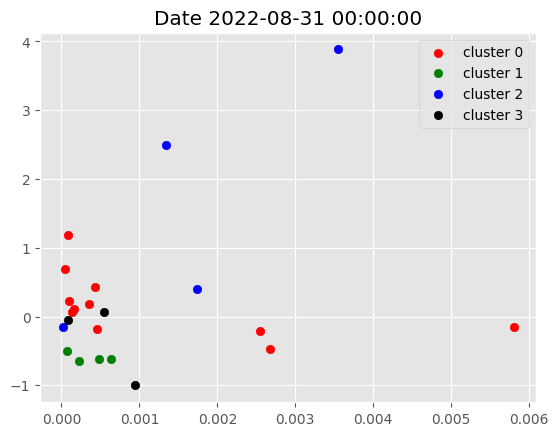

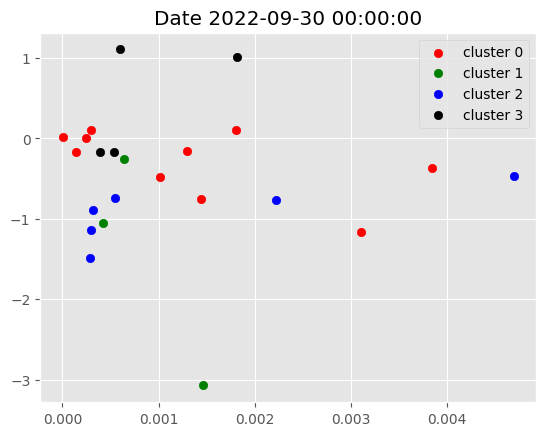

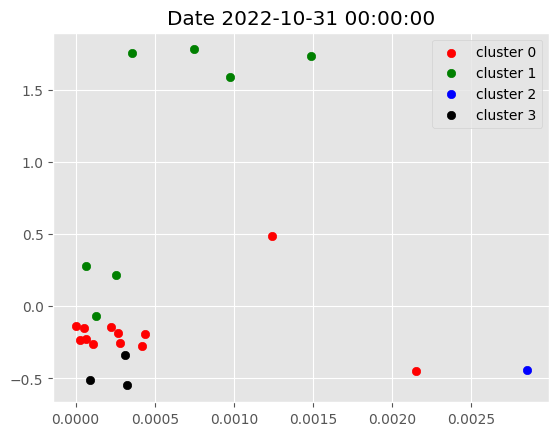

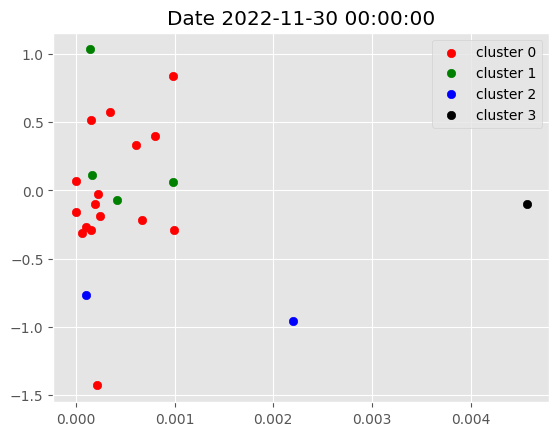

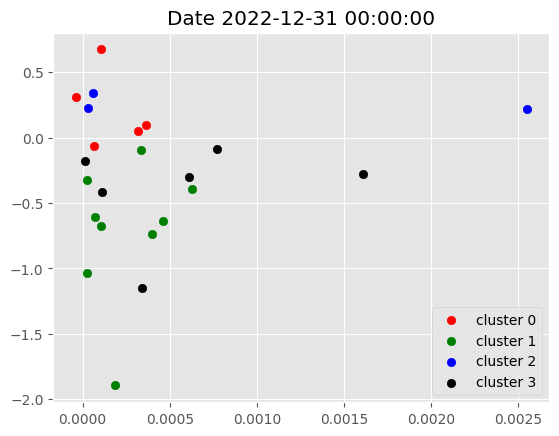

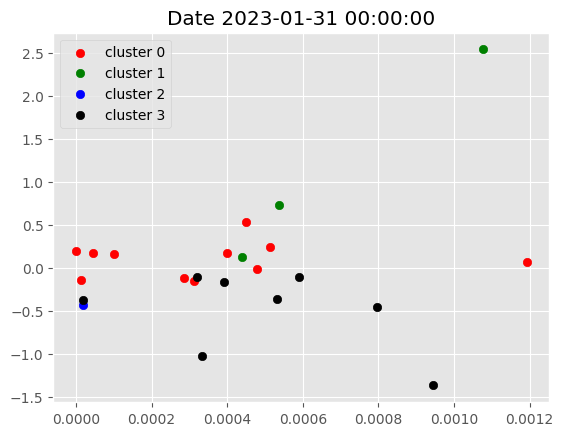

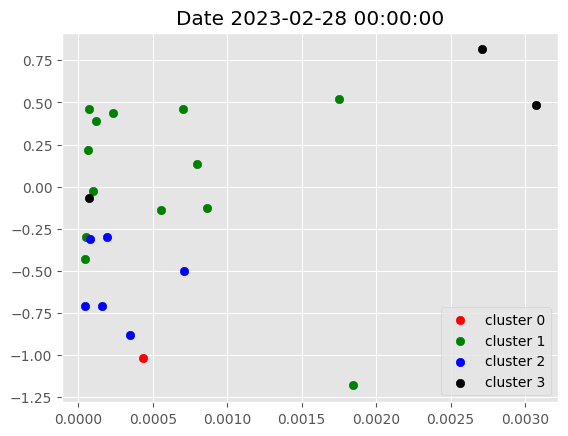

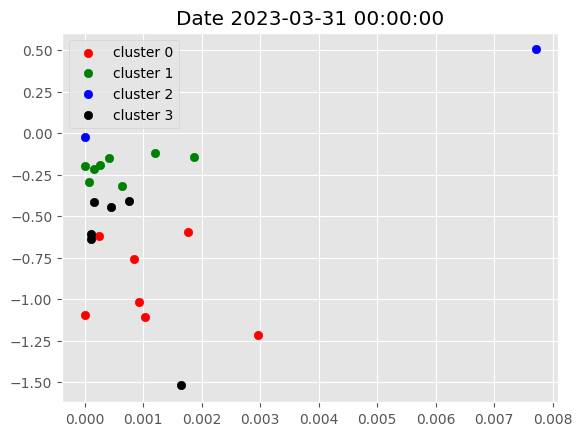

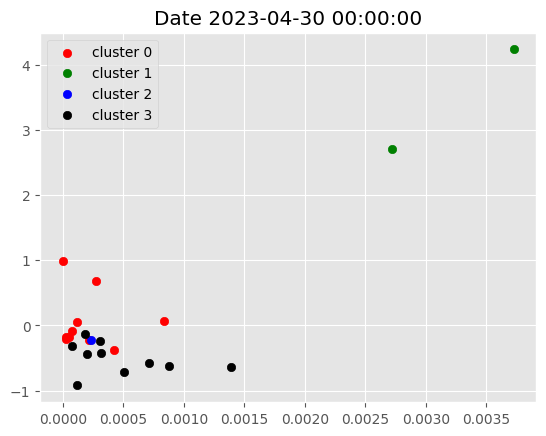

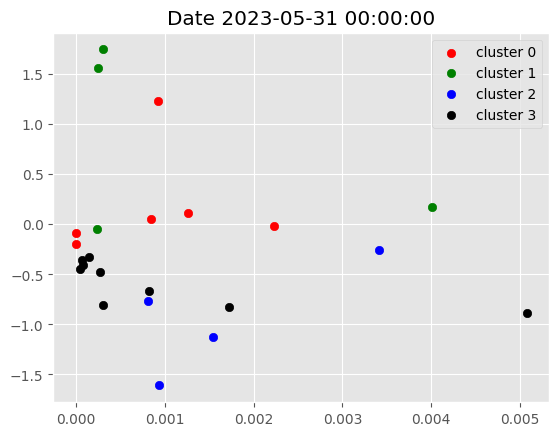

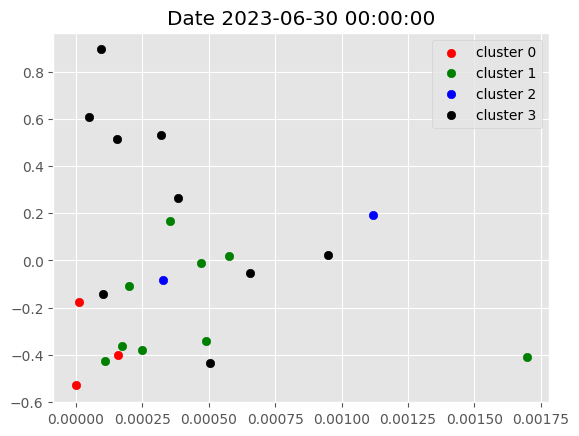

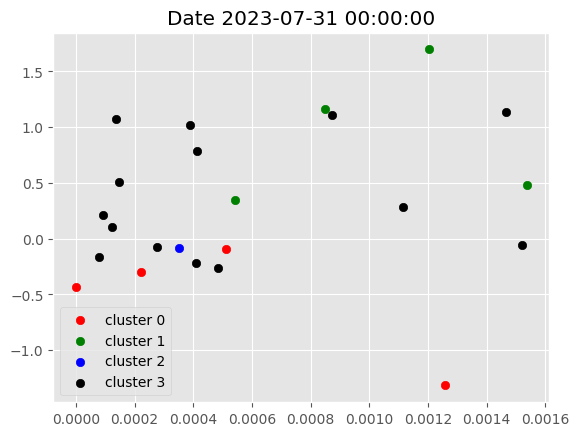

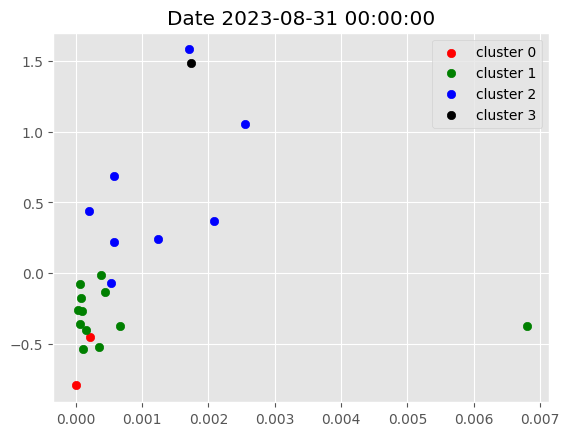

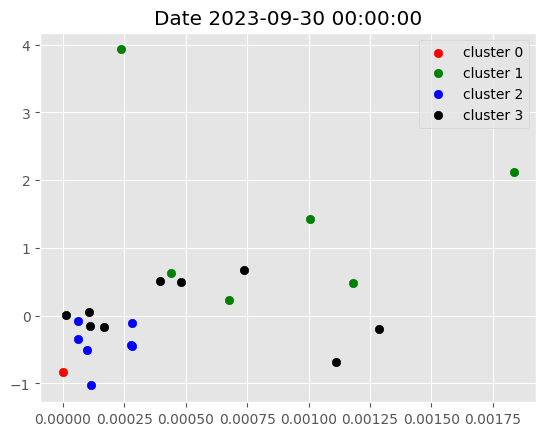

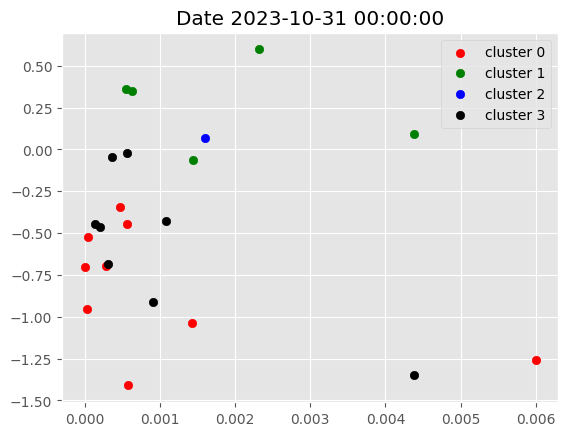

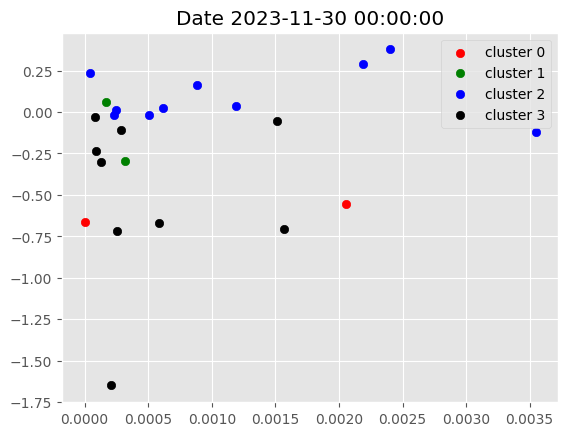

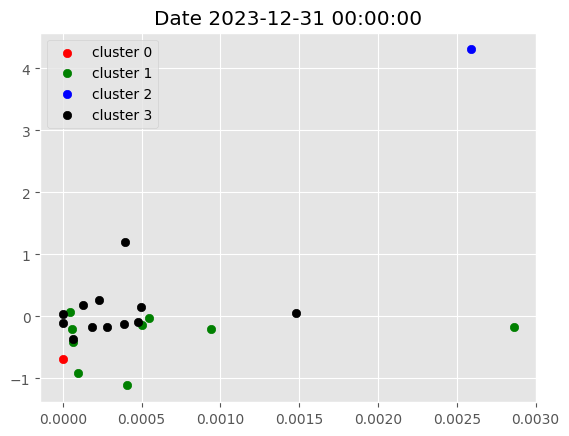

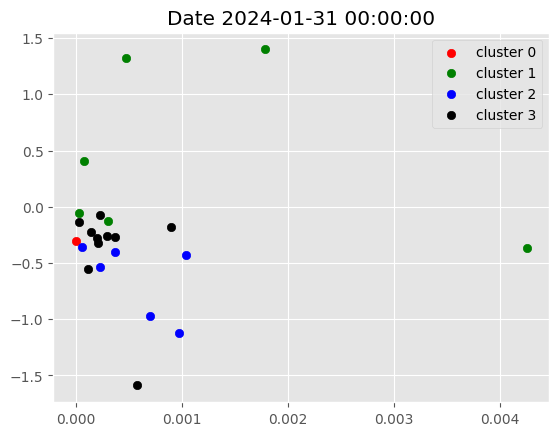

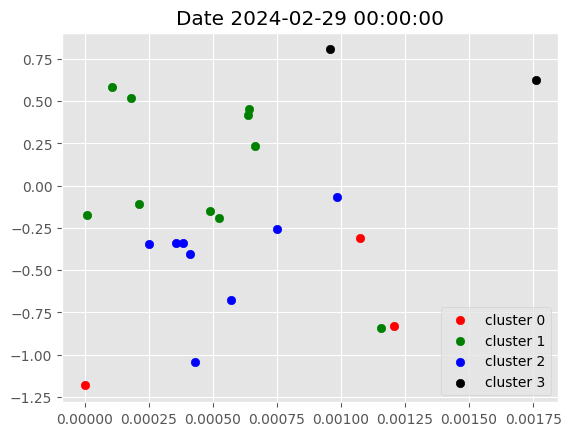

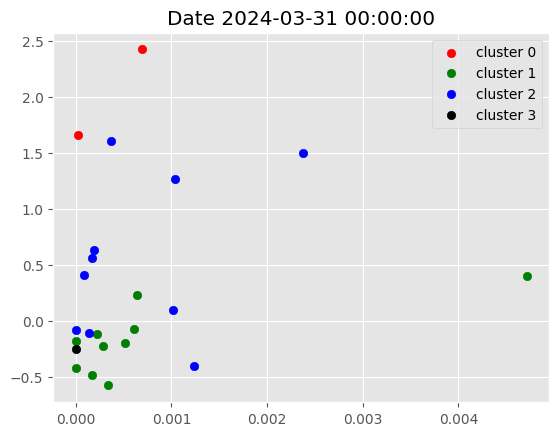

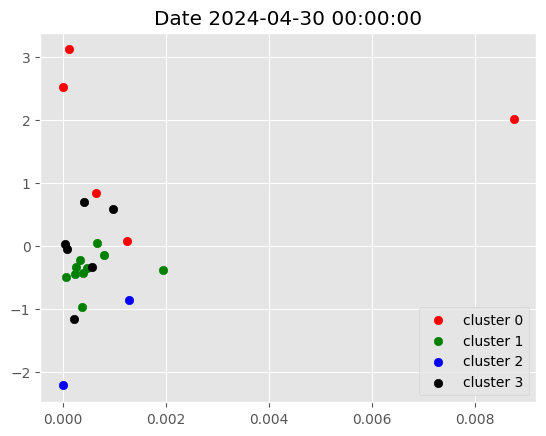

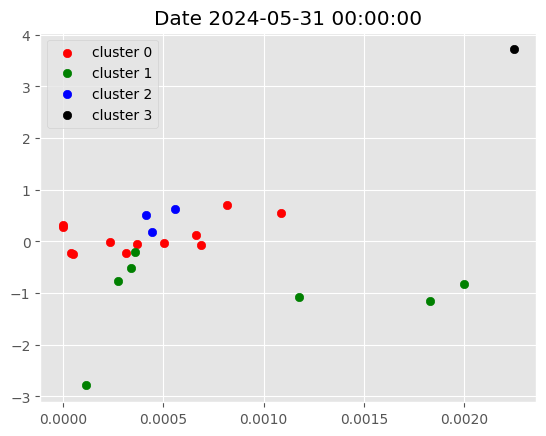

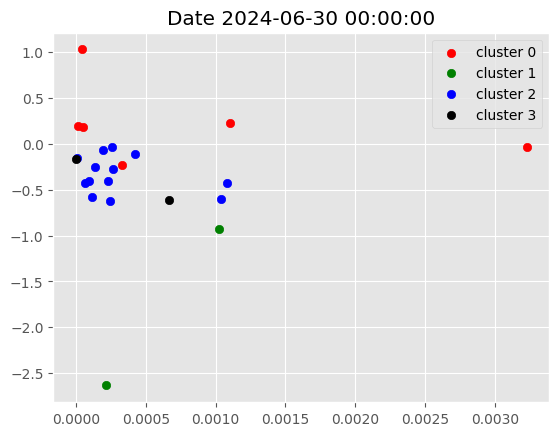

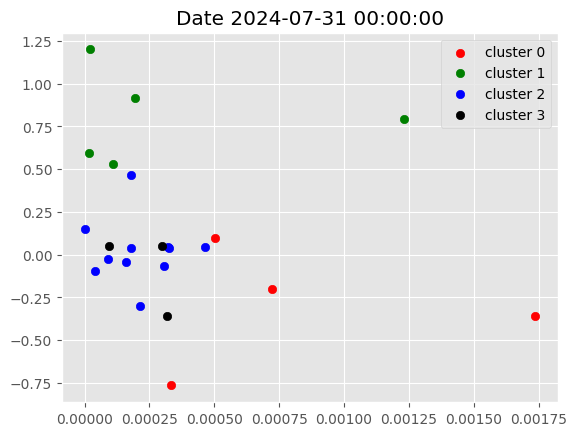

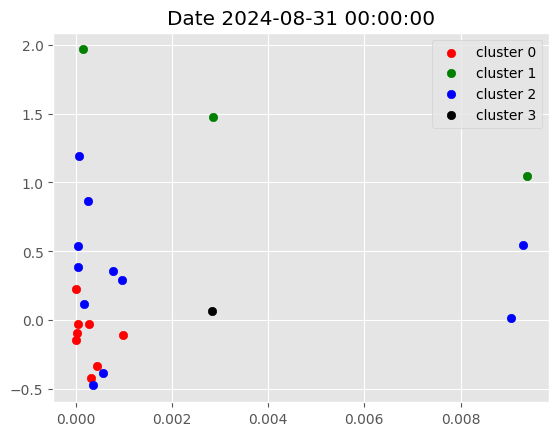

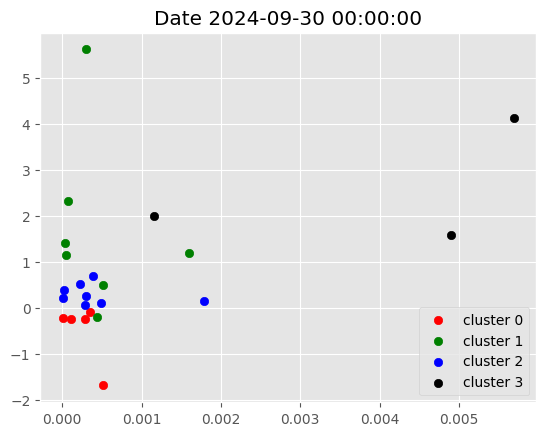

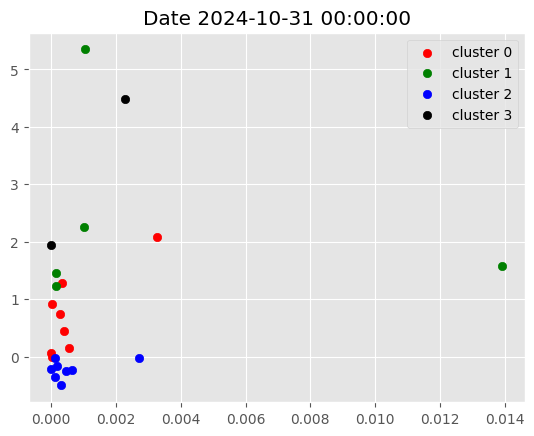

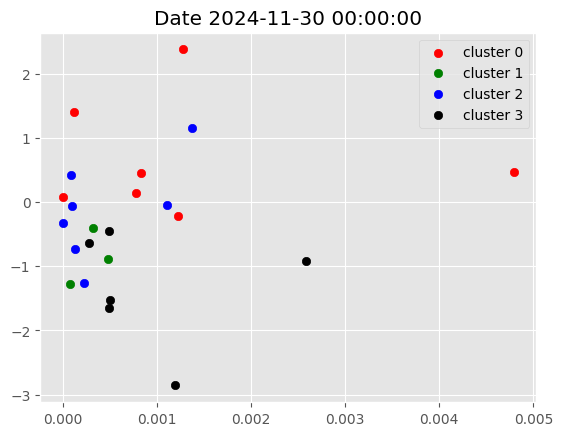

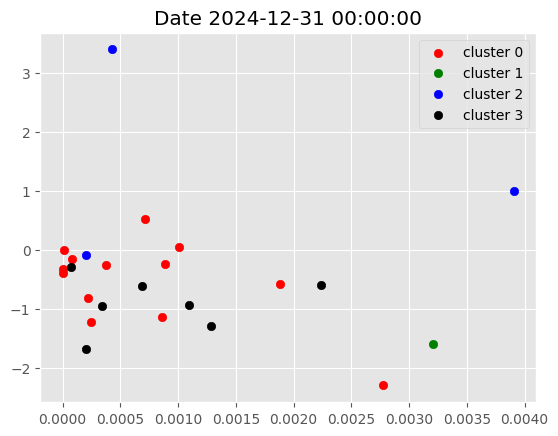

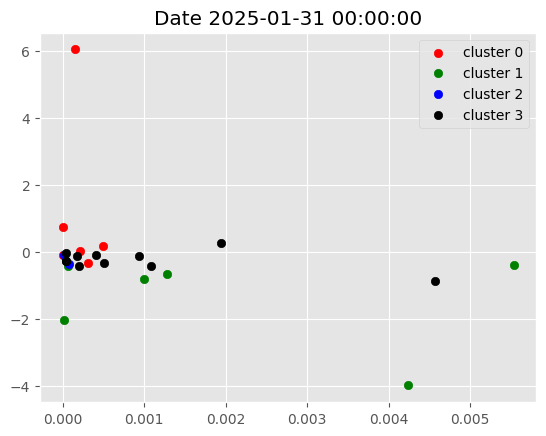

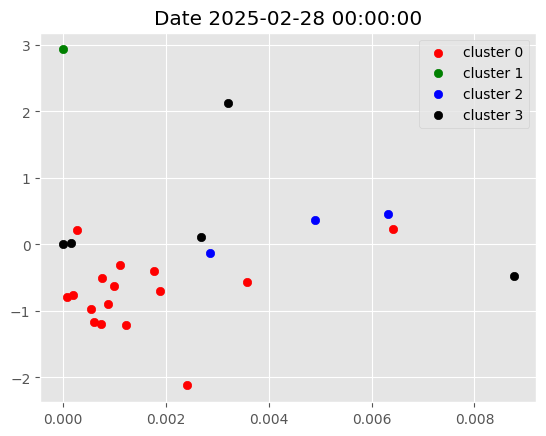

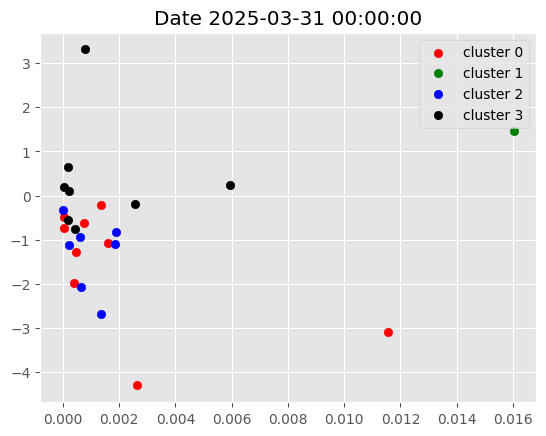

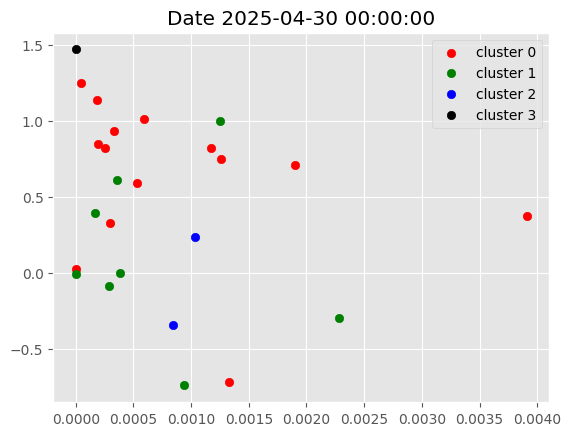

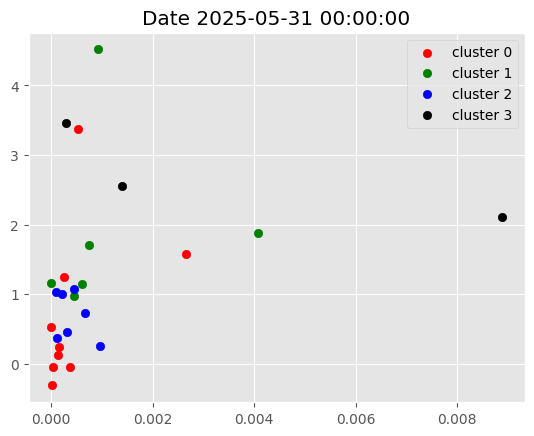

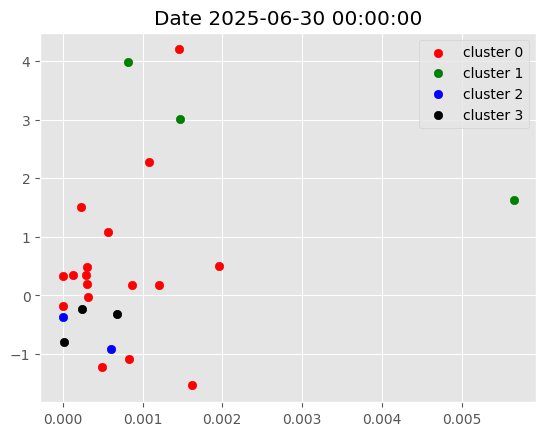

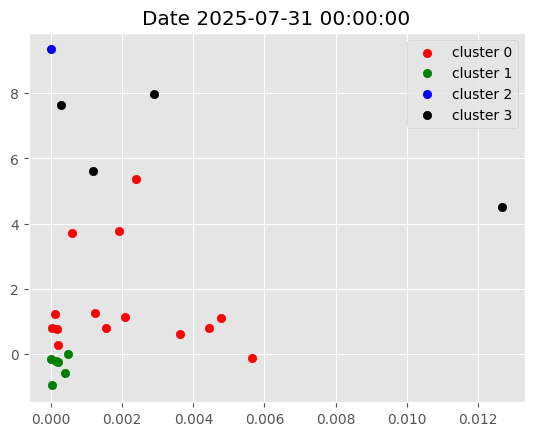

In [17]:
plt.style.use('ggplot')

for i in data.index.get_level_values('date').unique().tolist():
    g = data.xs(i, level=0)
    plt.title(f'Date {i}')
    plot_clusters(g)

### Apply pre-defined centroids.

In [21]:
target_rsi_values = [30, 45, 55, 70]
initial_centroids = np.zeros((len(target_rsi_values), 18))
initial_centroids[:, 6] = target_rsi_values

initial_centroids

array([[ 0.,  0.,  0.,  0.,  0.,  0., 30.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 45.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 55.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 70.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.]])

## 7. For each month select assets based on the cluster and form a portfolio based on Efficient Frontier max sharpe ratio optimization

* First we will filter only stocks corresponding to the cluster we choose based on our hypothesis.

* Momentum is persistent and my idea would be that stocks clustered around RSI 70 centroid should continue to outperform in the following month - thus I would select stocks corresponding to cluster 3.


In [22]:
filtered_df = data[data['cluster']==3].copy()

filtered_df = filtered_df.reset_index(level=1)
filtered_df.index = filtered_df.index+pd.DateOffset(1)
filtered_df = filtered_df.reset_index().set_index(['date', 'ticker'])
dates = filtered_df.index.get_level_values('date').unique().tolist()
fixed_dates = {}

for d in dates:

    fixed_dates[d.strftime('%Y-%m-%d')] = filtered_df.xs(d, level=0).index.tolist()

fixed_dates

{'2022-09-01': ['LSIP.JK', 'SIMP.JK', 'UNIC.JK'],
 '2022-10-01': ['BINA.JK', 'DNET.JK', 'MEDC.JK', 'MEGA.JK'],
 '2022-11-01': ['EMTK.JK', 'FAST.JK', 'SSIA.JK'],
 '2022-12-01': ['PANI.JK'],
 '2023-01-01': ['BRPT.JK',
  'ENRG.JK',
  'IMAS.JK',
  'MEDC.JK',
  'PANI.JK',
  'SIMP.JK'],
 '2023-02-01': ['BUMI.JK',
  'EMTK.JK',
  'ENRG.JK',
  'ICBP.JK',
  'INDF.JK',
  'TPIA.JK',
  'UNIC.JK',
  'UNSP.JK'],
 '2023-03-01': ['BINA.JK', 'BRPT.JK', 'IMAS.JK'],
 '2023-04-01': ['BUMI.JK',
  'LSIP.JK',
  'MEDC.JK',
  'SIMP.JK',
  'SSIA.JK',
  'UNSP.JK'],
 '2023-05-01': ['BUMI.JK',
  'EMTK.JK',
  'ENRG.JK',
  'FAST.JK',
  'LSIP.JK',
  'MEDC.JK',
  'MEGA.JK',
  'SIMP.JK',
  'UNIC.JK',
  'UNSP.JK'],
 '2023-06-01': ['BRPT.JK',
  'ENRG.JK',
  'IMJS.JK',
  'LSIP.JK',
  'MEDC.JK',
  'MEGA.JK',
  'SIMP.JK',
  'TPIA.JK',
  'UNIC.JK'],
 '2023-07-01': ['EMTK.JK',
  'FAST.JK',
  'ICBP.JK',
  'IMAS.JK',
  'IMJS.JK',
  'INDF.JK',
  'SIMP.JK',
  'SSIA.JK',
  'UNIC.JK'],
 '2023-08-01': ['BINA.JK',
  'BRMS.JK',
  'BRPT

### Define portfolio optimization function

* We will define a function which optimizes portfolio weights using PyPortfolioOpt package and EfficientFrontier optimizer to maximize the sharpe ratio.

* To optimize the weights of a given portfolio we would need to supply last 1 year prices to the function.

* Apply signle stock weight bounds constraint for diversification (minimum half of equaly weight and maximum 10% of portfolio).

In [ ]:
!pip install PyPortfolioOpt

In [24]:
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

def optimize_weights(prices, lower_bound=0):

    returns = expected_returns.mean_historical_return(prices=prices,
                                                      frequency=252)

    cov = risk_models.sample_cov(prices=prices,
                                 frequency=252)

    ef = EfficientFrontier(expected_returns=returns,
                           cov_matrix=cov,
                           weight_bounds=(lower_bound, .1),
                           solver='SCS')

    weights = ef.max_sharpe()

    return ef.clean_weights()

* Download Fresh Daily Prices Data only for short listed stocks.

In [37]:
stocks = data.index.get_level_values('ticker').unique().tolist()

new_df = yf.download(tickers=stocks,
                     start=data.index.get_level_values('date').unique()[0]-pd.DateOffset(months=12),
                     end=data.index.get_level_values('date').unique()[-1])

new_df

[*********************100%***********************]  25 of 25 completed


Price        Close                                                     \
Ticker     BINA.JK     BRMS.JK      BRPT.JK BUMI.JK   DCII.JK DEWA.JK   
Date                                                                    
2021-08-31  4580.0   80.752052  1051.619141    54.0   50700.0    50.0   
2021-09-01  4380.0   80.752052  1007.184509    54.0   49250.0    50.0   
2021-09-02  4430.0   79.823868  1002.247375    53.0   48000.0    50.0   
2021-09-03  4420.0   79.823868  1007.184509    56.0   46025.0    50.0   
2021-09-06  4190.0   83.536606   997.310181    56.0   42825.0    50.0   
...            ...         ...          ...     ...       ...     ...   
2025-07-24  4300.0  438.000000  2220.000000   116.0  346725.0   216.0   
2025-07-25  4300.0  430.000000  2480.000000   114.0  346725.0   218.0   
2025-07-28  4330.0  442.000000  2470.000000   115.0  346725.0   236.0   
2025-07-29  4320.0  470.000000  2610.000000   116.0  346725.0   232.0   
2025-07-30  4360.0  454.000000  2610.000000   115.0  346725.0   232.0   

Price                                                 ...     Volume  \
Ticker          DNET.JK      EMTK.JK ENRG.JK FAST.JK  ...    LSIP.JK   
Date                                                  ...              
2021-08-31  3178.369141  2000.291870   110.0   975.0  ...    9865500   
2021-09-01  3188.364014  1926.548340   109.0   975.0  ...    8137700   
2021-09-02  3228.343506  1880.458740   107.0   970.0  ...    9702300   
2021-09-03  3248.333252  1880.458740   115.0   975.0  ...   11914400   
2021-09-06  3238.338379  1926.548340   117.0   975.0  ...   11483500   
...                 ...          ...     ...     ...  ...        ...   
2025-07-24  9125.000000   587.500000   476.0   320.0  ...   25681600   
2025-07-25  9350.000000   607.415222   525.0   322.0  ...   17633100   
2025-07-28  9500.000000   617.372864   535.0   330.0  ...   10784400   
2025-07-29  9700.000000   607.415222   585.0   340.0  ...   16894400   
2025-07-30  9800.000000   632.309326   590.0   358.0  ...  124997400   

Price                                                                    \
Ticker        MEDC.JK MEGA.JK   PANI.JK    PTRO.JK    SIMP.JK   SSIA.JK   
Date                                                                      
2021-08-31   35032200    1918  14145645   15384000    1356900  35013300   
2021-09-01   35384400    6453   2031061   12886000    2917600  14310600   
2021-09-02  100663100   25464   1480718   10513000    2863200  10715200   
2021-09-03  121029900    6627   3901664   32069000    2086200  12111600   
2021-09-06   72858500    8720    958525   19089000    2217700  14863500   
...               ...     ...       ...        ...        ...       ...   
2025-07-24   42392400   11200  21534500   62509400   10827400  42825600   
2025-07-25   29396400    3000  19758000   82630300    8216500  27756900   
2025-07-28   17238300    8600  11617900  133948800   43347600  86824300   
2025-07-29   55396000    6100  12882200   56356300   18864400  68947000   
2025-07-30   55684900    2400  20871700   41644400  177905700  46901700   

Price                                  
Ticker       TPIA.JK UNIC.JK  UNSP.JK  
Date                                   
2021-08-31  18706800   31500   512000  
2021-09-01   8830800   29200   996500  
2021-09-02   5665200    5600  2284500  
2021-09-03  12355600    6800   358300  
2021-09-06  10222800    5000  1336800  
...              ...     ...      ...  
2025-07-24   5661800    6500   249500  
2025-07-25   5980100    1500   171100  
2025-07-28   9868300    1200   416300  
2025-07-29   6497200   11400    58900  
2025-07-30   4234600    3000  1182500  

[940 rows x 125 columns]

* Calculate daily returns for each stock which could land up in our portfolio.

* Then loop over each month start, select the stocks for the month and calculate their weights for the next month.

* If the maximum sharpe ratio optimization fails for a given month, apply equally-weighted weights.

* Calculated each day portfolio return.

In [42]:
returns_dataframe = np.log(new_df.loc[:, 'Close']).diff()
portfolio_df = pd.DataFrame()
for start_date in fixed_dates.keys():
    try:
        end_date = (pd.to_datetime(start_date)+pd.offsets.MonthEnd(0)).strftime('%Y-%m-%d')
        cols = fixed_dates[start_date]
        optimization_start_date = (pd.to_datetime(start_date)-pd.DateOffset(months=12)).strftime('%Y-%m-%d')
        optimization_end_date = (pd.to_datetime(start_date)-pd.DateOffset(days=1)).strftime('%Y-%m-%d')

        optimization_df = new_df.loc[optimization_start_date:optimization_end_date, 'Close'][cols]

        success = False
        try:
            weights = optimize_weights(prices=optimization_df,
                                   lower_bound=round(1/(len(optimization_df.columns)*2),3))

            weights = pd.DataFrame(weights, index=pd.Series(0)) # Ensures weights is a DataFrame with row index 0

            success = True
        except Exception as e:
            print(f'Max Sharpe Optimization failed for {start_date}, Continuing with Equal-Weights. Error: {e}')

        if success==False:
            # Ensure weights is a DataFrame with ticker index and single column 'weight'
            weights = pd.DataFrame([1/len(optimization_df.columns) for _ in range(len(optimization_df.columns))],
                                     index=optimization_df.columns.tolist(),
                                     columns=['weight']).T # Transpose to make tickers columns, then rename column
            weights = weights.T # Make tickers index

        # Prepare returns data
        temp_df_returns = returns_dataframe[start_date:end_date].stack().to_frame('return')
        # Convert 'ticker' index level to a column for merging
        temp_df_returns = temp_df_returns.reset_index(level='ticker')

        # Prepare weights for merge (ensure it has 'ticker' as index and 'weight' as column)
        if isinstance(weights.columns, pd.MultiIndex):
            weights_df_for_merge = weights.stack().to_frame('weight').reset_index(level=0, drop=True)
        elif len(weights.columns) == 1:
            weights_df_for_merge = weights.copy() # Assumes weights is already ticker indexed with 1 col
            weights_df_for_merge.columns = ['weight']
        else:
            # If weights is like {'ticker1': val1, 'ticker2': val2}, after pd.DataFrame it will be row 0, cols tickers
            weights_df_for_merge = weights.T # Transpose to make tickers the index
            weights_df_for_merge.columns = ['weight'] # Name the column

        # Merge returns with weights
        merged_temp_df = temp_df_returns.merge(weights_df_for_merge,
                                               left_on='ticker',
                                               right_index=True)

        merged_temp_df['weighted_return'] = merged_temp_df['return'] * merged_temp_df['weight']

        # Aggregate to daily strategy return
        temp_df = merged_temp_df.groupby(level=0)['weighted_return'].sum().to_frame('Strategy Return')
        temp_df.index.name = 'date'

        portfolio_df = pd.concat([portfolio_df, temp_df], axis=0)

    except Exception as e:
        print(f"An error occurred during portfolio construction for {start_date}: {e}")

portfolio_df = portfolio_df.drop_duplicates()

Max Sharpe Optimization failed for 2022-09-01, Continuing with Equal-Weights. Error: ('Please check your objectives/constraints or use a different solver.', 'Solver status: infeasible')
An error occurred during portfolio construction for 2022-09-01: 'ticker'
Max Sharpe Optimization failed for 2022-10-01, Continuing with Equal-Weights. Error: ('Please check your objectives/constraints or use a different solver.', 'Solver status: infeasible')
An error occurred during portfolio construction for 2022-10-01: 'ticker'
Max Sharpe Optimization failed for 2022-11-01, Continuing with Equal-Weights. Error: at least one of the assets must have an expected return exceeding the risk-free rate
An error occurred during portfolio construction for 2022-11-01: 'ticker'
Max Sharpe Optimization failed for 2022-12-01, Continuing with Equal-Weights. Error: ('Please check your objectives/constraints or use a different solver.', 'Solver status: infeasible')
An error occurred during portfolio construction for 2

## 8. Visualize Portfolio returns and compare to SP500 returns.

In [39]:
jkse = yf.download(tickers="^JKSE",
                  start='2019-01-01',
                  end=dt.date.today())

jkse_close_col = None

# Try to find the 'Adj Close' or 'Close' column using a more robust method
if 'Adj Close' in jkse.columns:
    jkse_close_col = jkse['Adj Close']
elif 'Close' in jkse.columns:
    jkse_close_col = jkse['Close']
elif isinstance(jkse.columns, pd.MultiIndex):
    for col_tuple in jkse.columns:
        # Assuming jkse[col_tuple] returns a Series, if it's the leaf tuple
        # If it returns a DataFrame (as kernel state suggests), we handle it below
        if 'Adj Close' in col_tuple:
            jkse_close_col = jkse[col_tuple]
            break
        elif 'Close' in col_tuple:
            jkse_close_col = jkse[col_tuple]
            break

if jkse_close_col is not None:
    # If jkse_close_col is already a DataFrame (as shown in kernel state), .to_frame() will error.
    # We need to compute log returns and then rename the column.
    jkse_ret = np.log(jkse_close_col).diff().dropna()
    # Ensure jkse_ret is a DataFrame and rename its column
    if isinstance(jkse_ret, pd.Series):
        jkse_ret = jkse_ret.to_frame('JKSE Buy&Hold')
    elif isinstance(jkse_ret, pd.DataFrame) and len(jkse_ret.columns) == 1:
        jkse_ret.columns = ['JKSE Buy&Hold']
    else:
        print("Warning: Unexpected structure for jkse_ret. Creating empty returns DataFrame.")
        jkse_ret = pd.DataFrame(columns=['JKSE Buy&Hold'])

else:
    print("Warning: Could not find 'Adj Close' or 'Close' column in jkse DataFrame. Creating empty returns DataFrame.")
    jkse_ret = pd.DataFrame(columns=['JKSE Buy&Hold']) # Ensure it's always a DataFrame

portfolio_df = portfolio_df.merge(jkse_ret,
                                  left_index=True,
                                  right_index=True)

portfolio_df

[*********************100%***********************]  1 of 1 completed


,JKSE Buy&Hold


In [40]:
import matplotlib.ticker as mtick

plt.style.use('ggplot')

portfolio_cumulative_return = np.exp(np.log1p(portfolio_df).cumsum())-1

portfolio_cumulative_return[:'2023-09-29'].plot(figsize=(16,6))

plt.title('Unsupervised Learning Trading Strategy Returns Over Time')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.ylabel('Return')

plt.show()


TypeError: cannot do slice indexing on RangeIndex with these indexers [2023-09-29] of type str

# Twitter Sentiment Investing Strategy

## 1. Load Twitter Sentiment Data

* Load the twitter sentiment dataset, set the index, calculat engagement ratio and filter out stocks with no significant twitter activity.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf
import os
plt.style.use('ggplot')

data_folder = 'C:/Users/user/Desktop/Python Scripts'

sentiment_df = pd.read_csv(os.path.join(data_folder, 'sentiment_data.csv'))

sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

sentiment_df = sentiment_df.set_index(['date', 'symbol'])

sentiment_df['engagement_ratio'] = sentiment_df['twitterComments']/sentiment_df['twitterLikes']

sentiment_df = sentiment_df[(sentiment_df['twitterLikes']>20)&(sentiment_df['twitterComments']>10)]

sentiment_df

## 2. Aggregate Monthly and calculate average sentiment for the month

* Aggregate on a monthly level and calculate average monthly metric, for the one we choose.

In [ ]:
aggragated_df = (sentiment_df.reset_index('symbol').groupby([pd.Grouper(freq='M'), 'symbol'])
                    [['engagement_ratio']].mean())

aggragated_df['rank'] = (aggragated_df.groupby(level=0)['engagement_ratio']
                         .transform(lambda x: x.rank(ascending=False)))

aggragated_df

## 3. Select Top 5 Stocks based on their cross-sectional ranking for each month

* Select top 5 stocks by rank for each month and fix the date to start at beginning of next month.

In [ ]:
filtered_df = aggragated_df[aggragated_df['rank']<6].copy()

filtered_df = filtered_df.reset_index(level=1)

filtered_df.index = filtered_df.index+pd.DateOffset(1)

filtered_df = filtered_df.reset_index().set_index(['date', 'symbol'])

filtered_df.head(20)

## 4. Extract the stocks to form portfolios with at the start of each new month

* Create a dictionary containing start of month and corresponded selected stocks.

In [ ]:
dates = filtered_df.index.get_level_values('date').unique().tolist()

fixed_dates = {}

for d in dates:

    fixed_dates[d.strftime('%Y-%m-%d')] = filtered_df.xs(d, level=0).index.tolist()

fixed_dates

## 5. Download fresh stock prices for only selected/shortlisted stocks

In [ ]:
stocks_list = sentiment_df.index.get_level_values('symbol').unique().tolist()

prices_df = yf.download(tickers=stocks_list,
                        start='2021-01-01',
                        end='2023-03-01')

## 6. Calculate Portfolio Returns with monthly rebalancing


In [ ]:
returns_df = np.log(prices_df['Adj Close']).diff().dropna()

portfolio_df = pd.DataFrame()

for start_date in fixed_dates.keys():

    end_date = (pd.to_datetime(start_date)+pd.offsets.MonthEnd()).strftime('%Y-%m-%d')

    cols = fixed_dates[start_date]

    temp_df = returns_df[start_date:end_date][cols].mean(axis=1).to_frame('portfolio_return')

    portfolio_df = pd.concat([portfolio_df, temp_df], axis=0)

portfolio_df

## 7. Download NASDAQ/QQQ prices and calculate returns to compare to our strategy

In [ ]:
qqq_df = yf.download(tickers='QQQ',
                     start='2021-01-01',
                     end='2023-03-01')

qqq_ret = np.log(qqq_df['Adj Close']).diff().to_frame('nasdaq_return')

portfolio_df = portfolio_df.merge(qqq_ret,
                                  left_index=True,
                                  right_index=True)

portfolio_df

In [ ]:
portfolios_cumulative_return = np.exp(np.log1p(portfolio_df).cumsum()).sub(1)

portfolios_cumulative_return.plot(figsize=(16,6))

plt.title('Twitter Engagement Ratio Strategy Return Over Time')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.ylabel('Return')

plt.show()

# Intraday Strategy Using GARCH Model


* Using simulated daily data and intraday 5-min data.
* Load Daily and 5-minute data.
* Define function to fit GARCH model on the daily data and predict 1-day ahead volatility in a rolling window.
* Calculate prediction premium and form a daily signal from it.
* Merge with intraday data and calculate intraday indicators to form the intraday signal.
* Generate the position entry and hold until the end of the day.
* Calculate final strategy returns.

## 1. Load Simulated Daily and Simulated 5-minute data.

* We are loading both datasets, set the indexes and calculate daily log returns.

In [ ]:
import matplotlib.pyplot as plt
from arch import arch_model
import pandas_ta
import pandas as pd
import numpy as np
import os

data_folder = 'C:/Users/user/Desktop/Python Scripts'

daily_df = pd.read_csv(os.path.join(data_folder, 'simulated_daily_data.csv'))

daily_df = daily_df.drop('Unnamed: 7', axis=1)

daily_df['Date'] = pd.to_datetime(daily_df['Date'])

daily_df = daily_df.set_index('Date')


intraday_5min_df = pd.read_csv(os.path.join(data_folder, 'simulated_5min_data.csv'))

intraday_5min_df = intraday_5min_df.drop('Unnamed: 6', axis=1)

intraday_5min_df['datetime'] = pd.to_datetime(intraday_5min_df['datetime'])

intraday_5min_df = intraday_5min_df.set_index('datetime')

intraday_5min_df['date'] = pd.to_datetime(intraday_5min_df.index.date)

intraday_5min_df

## 2. Define function to fit GARCH model and predict 1-day ahead volatility in a rolling window.

* We are first calculating the 6-month rolling variance and then we are creating a function in a 6-month rolling window to fit a garch model and predict the next day variance.

In [ ]:
daily_df['log_ret'] = np.log(daily_df['Adj Close']).diff()

daily_df['variance'] = daily_df['log_ret'].rolling(180).var()

daily_df = daily_df['2020':]

def predict_volatility(x):

    best_model = arch_model(y=x,
                            p=1,
                            q=3).fit(update_freq=5,
                                     disp='off')

    variance_forecast = best_model.forecast(horizon=1).variance.iloc[-1,0]

    print(x.index[-1])

    return variance_forecast

daily_df['predictions'] = daily_df['log_ret'].rolling(180).apply(lambda x: predict_volatility(x))

daily_df = daily_df.dropna()

daily_df

## 3. Calculate prediction premium and form a daily signal from it.

* We are calculating the prediction premium. And calculate its 6-month rolling standard deviation.

* From this we are creating our daily signal.

In [ ]:
daily_df['prediction_premium'] = (daily_df['predictions']-daily_df['variance'])/daily_df['variance']

daily_df['premium_std'] = daily_df['prediction_premium'].rolling(180).std()

daily_df['signal_daily'] = daily_df.apply(lambda x: 1 if (x['prediction_premium']>x['premium_std'])
                                         else (-1 if (x['prediction_premium']<x['premium_std']*-1) else np.nan),
                                         axis=1)

daily_df['signal_daily'] = daily_df['signal_daily'].shift()

daily_df

In [ ]:
plt.style.use('ggplot')

daily_df['signal_daily'].plot(kind='hist')

plt.show()

## 4. Merge with intraday data and calculate intraday indicators to form the intraday signal.

* Calculate all intraday indicators and intraday signal.

In [ ]:
final_df = intraday_5min_df.reset_index()\
                            .merge(daily_df[['signal_daily']].reset_index(),
                                   left_on='date',
                                   right_on='Date')\
                            .drop(['date','Date'], axis=1)\
                            .set_index('datetime')

final_df['rsi'] = pandas_ta.rsi(close=final_df['close'],
                                length=20)

final_df['lband'] = pandas_ta.bbands(close=final_df['close'],
                                     length=20).iloc[:,0]

final_df['uband'] = pandas_ta.bbands(close=final_df['close'],
                                     length=20).iloc[:,2]

final_df['signal_intraday'] = final_df.apply(lambda x: 1 if (x['rsi']>70)&
                                                            (x['close']>x['uband'])
                                             else (-1 if (x['rsi']<30)&
                                                         (x['close']<x['lband']) else np.nan),
                                             axis=1)

final_df['return'] = np.log(final_df['close']).diff()

final_df

## 5. Generate the position entry and hold until the end of the day.

In [ ]:
final_df['return_sign'] = final_df.apply(lambda x: -1 if (x['signal_daily']==1)&(x['signal_intraday']==1)
                                        else (1 if (x['signal_daily']==-1)&(x['signal_intraday']==-1) else np.nan),
                                        axis=1)

final_df['return_sign'] = final_df.groupby(pd.Grouper(freq='D'))['return_sign']\
                                  .transform(lambda x: x.ffill())

final_df['forward_return'] = final_df['return'].shift(-1)

final_df['strategy_return'] = final_df['forward_return']*final_df['return_sign']

daily_return_df = final_df.groupby(pd.Grouper(freq='D'))['strategy_return'].sum()

## 6. Calculate final strategy returns.

In [ ]:
import matplotlib.ticker as mtick

strategy_cumulative_return = np.exp(np.log1p(daily_return_df).cumsum()).sub(1)

strategy_cumulative_return.plot(figsize=(16,6))

plt.title('Intraday Strategy Returns')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.ylabel('Return')

plt.show()
